# Factor Investing — Multi-Factor Smart Beta

This notebook implements a four-factor smart beta model designed to mimic
Betterment's Goldman Sachs Smart Beta portfolio — the most clearly documented
factor-based robo-advisor in the industry.

**Primary citation**: Barber, J., Bennett, S., & Gvozdeva, E. (2015).
*How to Choose a Strategic Multi-Factor Equity Portfolio.*
Russell Investments. Found 34–40% improvement in Sharpe ratio over benchmark.

**Robo-advisor reference**: Betterment Goldman Sachs Smart Beta portfolio.
Uses value, momentum, quality, and low volatility with equal factor weighting.
Source: betterment.com/resources/smart-beta-portfolio-methodology

**The four factors and their academic foundations:**
- **Value**: Inverse of 3-year cumulative return (ETF-level proxy for relative cheapness)
  — Fama & French (1993), *Journal of Financial Economics*
- **Momentum**: 12-month return, skipping last month (standard price momentum)
  — Jegadeesh & Titman (1993), *Journal of Finance*
- **Quality**: Sharpe ratio over 36 months (return per unit of risk, ETF-level proxy)
  — Novy-Marx (2013), *Journal of Financial Economics*
- **Low Volatility**: Inverse of 12-month rolling volatility (lower vol = higher score)
  — Frazzini & Pedersen (2014), *Journal of Financial Economics*

**How it works**: Each month, every ETF is scored on all four factors.
Scores are z-score normalized so all factors are on the same scale.
The four z-scores are combined into a single composite score with equal weights
(matching Betterment's equal-factor-weighting methodology).
Portfolio weights are assigned proportional to composite score.

Assets: `BND, GLD, TIP, TLT, VEU, VGT`

In [19]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────────
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

with open("../../markets.json") as f:
    config = json.load(f)

market_name        = list(config["markets"].keys())[0]
data_folder        = Path("../../data")
initial_investment = config["initial_investment"]
monthly_investment = config["monthly_investment"]

In [20]:
# ── Key parameters ─────────────────────────────────────────────────────────────
LOOKBACK            = 36   # months of past data available each period
REBALANCE_THRESHOLD = 0.05 # only rebalance if any weight drifts more than 5%

# ── Momentum window ───────────────────────────────────────────────────────────
# Standard Jegadeesh-Titman (1993): use months t-13 to t-2.
# That is 12 months of signal, skipping the most recent month (t-1)
# to avoid short-term reversal contamination.
# In index terms within a 36-row window:
#   MOMENTUM_START = -13 (13 months back)
#   MOMENTUM_END   = -1  (skip last month)
MOMENTUM_START = -13
MOMENTUM_END   = -1

# ── Value window ──────────────────────────────────────────────────────────────
# Uses the OLDER part of the window: months t-36 to t-13.
# This captures long-run mean reversion (value) separately from
# short-run momentum. Non-overlapping windows ensure the two factors
# provide distinct signals rather than cancelling each other out.
# Fama & French (1993) documented the value premium over long horizons.
VALUE_START = -36  # start of window (oldest)
VALUE_END   = -13  # end of window (does not overlap with momentum)

# ── Low volatility window ────────────────────────────────────────────────────
LOW_VOL_LOOKBACK = 12  # trailing 12 months, same as Betterment GS methodology

# ── Crisis periods for chart shading ─────────────────────────────────────────
CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

# ── Color palette ─────────────────────────────────────────────────────────────
PALETTE = {
    "Factor Investing": "#E53E3E",
    "Equal Weight"    : "#028090",
}

plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market            : {market_name}")
print(f"Rolling window    : {LOOKBACK} months")
print(f"Rebal threshold   : {REBALANCE_THRESHOLD*100:.0f}%")
print(f"Momentum window   : months {MOMENTUM_START} to {MOMENTUM_END} (12 months, skip last)")
print(f"Value window      : months {VALUE_START} to {VALUE_END} (non-overlapping with momentum)")
print(f"Low vol window    : trailing {LOW_VOL_LOOKBACK} months")

Market            : primary_total_market
Rolling window    : 36 months
Rebal threshold   : 5%
Momentum window   : months -13 to -1 (12 months, skip last)
Value window      : months -36 to -13 (non-overlapping with momentum)
Low vol window    : trailing 12 months


In [21]:
returns = pd.read_csv(
    data_folder / f"{market_name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)
returns = returns.dropna()

assets     = list(returns.columns)
num_assets = len(assets)

# Build cumulative price index from returns (base = 1.0 at start)
# Used for momentum and value score computation
price_index = (1 + returns).cumprod()

print(f"Period : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"Assets : {assets}")
print(f"Months : {len(returns)}")

Period : 2007-05-01 -> 2025-12-01
Assets : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Months : 224


In [22]:
# ── Cell 3: Rolling Risk-Free Rate ────────────────────────────────────────────
risk_free_file = data_folder / "risk_free_monthly.csv"

if risk_free_file.exists():
    risk_free_data        = pd.read_csv(risk_free_file, index_col=0, parse_dates=True)
    risk_free_data        = risk_free_data.reindex(returns.index, method="ffill")
    annual_rf_series      = risk_free_data["rf_annual"]
    monthly_rf_series     = risk_free_data["rf_monthly"]
    avg_annual_risk_free  = annual_rf_series.mean()
    avg_monthly_risk_free = monthly_rf_series.mean()
    print(f"Rolling RF loaded  : {len(risk_free_data)} months")
    print(f"  Range  : {annual_rf_series.min()*100:.2f}% - {annual_rf_series.max()*100:.2f}%")
    print(f"  Average: {avg_annual_risk_free*100:.3f}% annual")
else:
    print("WARNING: risk_free_monthly.csv not found. Run main.ipynb first.")
    avg_annual_risk_free  = 0.0351
    avg_monthly_risk_free = (1 + avg_annual_risk_free) ** (1/12) - 1
    annual_rf_series      = pd.Series(avg_annual_risk_free,  index=returns.index)
    monthly_rf_series     = pd.Series(avg_monthly_risk_free, index=returns.index)

Rolling RF loaded  : 224 months
  Range  : 0.01% - 5.34%
  Average: 1.415% annual


In [23]:
# ── Cell 4: Factor Scoring Functions ─────────────────────────────────────────
# Four factor scores computed at the ETF level.
# All proxies are adapted from stock-level factor definitions
# to work with broad asset class ETFs.
#
# CRITICAL DESIGN DECISION — Non-overlapping windows for value and momentum:
#   Momentum uses months t-13 to t-2 (recent 12 months, skip last)
#   Value    uses months t-36 to t-13 (older 24 months)
# This ensures the two factors capture distinct signals.
# If both used the same window they would be near-perfectly negatively
# correlated and cancel each other out in the composite score.

def compute_momentum_score(return_window, momentum_start, momentum_end):
    """
    Momentum: 12-month cumulative return, skipping most recent month.
    Uses months t-13 to t-2 within the rolling window.

    Jegadeesh & Titman (1993): assets that performed well over 3-12 months
    continue to perform well. Skip last month avoids short-term reversal.
    Higher score = stronger recent performance = more momentum.
    """
    # momentum_end is -1 so iloc[start:-1] correctly excludes the last row
    momentum_window   = return_window.iloc[momentum_start : momentum_end]
    cumulative_return = (1 + momentum_window).prod() - 1
    return cumulative_return


def compute_value_score(return_window, value_start, value_end):
    """
    Value: inverse of long-run cumulative return (months t-36 to t-13).
    This window is deliberately non-overlapping with momentum.

    ETF-level proxy: assets that have underperformed over the long run
    are relatively 'cheap' — a mean-reversion argument.
    Fama & French (1993): value premium persists over long horizons.
    Inverse ensures lower long-run return = higher value score.
    """
    value_window      = return_window.iloc[value_start : value_end]
    cumulative_return = (1 + value_window).prod() - 1
    # Invert: what has lagged long-run is the 'cheap' asset
    value_score = -cumulative_return
    return value_score


def compute_quality_score(return_window, monthly_rf):
    """
    Quality: annualized Sharpe ratio over the full 36-month window.
    ETF-level proxy for Novy-Marx (2013) profitability / Asness et al. (2019) QMJ.

    A high-quality ETF delivers consistent risk-adjusted returns.
    Higher Sharpe = more return per unit of risk = higher quality.
    Uses the full lookback window for maximum statistical stability.
    """
    mean_excess_return = return_window.mean() - monthly_rf
    return_std         = return_window.std()
    sharpe_ratio       = mean_excess_return / return_std.replace(0, np.nan)
    return sharpe_ratio.fillna(0) * np.sqrt(12)  # annualized


def compute_low_volatility_score(return_window, vol_lookback):
    """
    Low Volatility: inverse of trailing 12-month annualized volatility.
    Frazzini & Pedersen (2014): low-beta/low-vol assets earn higher
    risk-adjusted returns than CAPM predicts — the BAB premium.
    Inverse ensures lower volatility = higher score.
    """
    vol_window    = return_window.iloc[-vol_lookback:]
    volatility    = vol_window.std() * np.sqrt(12)  # annualized
    low_vol_score = 1 / volatility.replace(0, np.nan)
    return low_vol_score.fillna(0)


def normalize_to_z_scores(factor_scores):
    """
    Z-score normalize factor scores so all factors are on the same scale.
    Required before combining — otherwise factors measured in different
    units would dominate the composite score.
    With only 6 assets the cross-sectional std is small but normalization
    still ensures equal factor influence in the composite.
    """
    score_mean = factor_scores.mean()
    score_std  = factor_scores.std()
    if score_std == 0 or np.isnan(score_std):
        return factor_scores * 0
    return (factor_scores - score_mean) / score_std


def compute_factor_weights(composite_scores):
    """
    Convert composite scores to portfolio weights.
    Shift scores so minimum is zero (no negative weights).
    Normalize so weights sum to 1.
    Assets with higher composite scores receive higher portfolio weight.
    """
    shifted_scores = composite_scores - composite_scores.min()
    total_score    = shifted_scores.sum()
    if total_score == 0:
        return pd.Series(
            np.ones(len(composite_scores)) / len(composite_scores),
            index=composite_scores.index
        )
    return shifted_scores / total_score


print("Factor scoring functions defined.")
print()
print("Window design (within each 36-month rolling window):")
print("  Momentum  : months t-13 to t-2  (12 months, skip most recent)")
print("  Value     : months t-36 to t-13 (24 months, NON-OVERLAPPING with momentum)")
print("  Quality   : months t-36 to t-1  (full 36-month window)")
print("  Low Vol   : months t-12 to t-1  (trailing 12 months)")
print()
print("Citations:")
print("  Momentum    — Jegadeesh & Titman (1993), Journal of Finance")
print("  Value       — Fama & French (1993), Journal of Financial Economics")
print("  Quality     — Novy-Marx (2013) / Asness et al. (2019)")
print("  Low Vol     — Frazzini & Pedersen (2014), Journal of Financial Economics")
print("  Combination — Equal weighting, Barber et al. (2015), Russell Investments")

Factor scoring functions defined.

Window design (within each 36-month rolling window):
  Momentum  : months t-13 to t-2  (12 months, skip most recent)
  Value     : months t-36 to t-13 (24 months, NON-OVERLAPPING with momentum)
  Quality   : months t-36 to t-1  (full 36-month window)
  Low Vol   : months t-12 to t-1  (trailing 12 months)

Citations:
  Momentum    — Jegadeesh & Titman (1993), Journal of Finance
  Value       — Fama & French (1993), Journal of Financial Economics
  Quality     — Novy-Marx (2013) / Asness et al. (2019)
  Low Vol     — Frazzini & Pedersen (2014), Journal of Financial Economics
  Combination — Equal weighting, Barber et al. (2015), Russell Investments


In [24]:
# ── Cell 5: Rolling Simulation ────────────────────────────────────────────────
# Every month:
#   1. Compute four factor scores from the past LOOKBACK months
#      - Momentum: months t-13 to t-2 (12 months, skip last)
#      - Value:    months t-36 to t-13 (non-overlapping with momentum)
#      - Quality:  full 36-month window Sharpe ratio
#      - Low Vol:  trailing 12-month inverse volatility
#   2. Z-score normalize each factor score cross-sectionally
#   3. Combine with equal weights (25% each) into composite score
#   4. Convert composite scores to portfolio weights
#   5. Apply rebalancing threshold — only trade if drift exceeds 5%
#   6. Earn next month's return
#
# Requires minimum LOOKBACK=36 months before simulation begins.
# The value window needs the full 36 months to compute long-run signal.

rolling_weight_history = []
rolling_return_history = []
rolling_date_history   = []
monthly_turnover       = []
factor_score_history   = []

current_weights = np.ones(num_assets) / num_assets

for month_index in range(LOOKBACK, len(returns)):
    return_window = returns.iloc[month_index - LOOKBACK : month_index]
    monthly_rf    = monthly_rf_series.iloc[month_index]

    # ── Compute raw factor scores ─────────────────────────────────────────────
    momentum_raw = compute_momentum_score(
        return_window, MOMENTUM_START, MOMENTUM_END
    )
    value_raw    = compute_value_score(
        return_window, VALUE_START, VALUE_END
    )
    quality_raw  = compute_quality_score(
        return_window, monthly_rf
    )
    low_vol_raw  = compute_low_volatility_score(
        return_window, LOW_VOL_LOOKBACK
    )

    # ── Z-score normalize each factor cross-sectionally ───────────────────────
    # Each factor is normalized independently across the 6 assets.
    # This ensures each factor contributes equally to the composite
    # regardless of its raw scale.
    momentum_z = normalize_to_z_scores(momentum_raw)
    value_z    = normalize_to_z_scores(value_raw)
    quality_z  = normalize_to_z_scores(quality_raw)
    low_vol_z  = normalize_to_z_scores(low_vol_raw)

    # ── Equal-weight composite (Betterment GS Smart Beta methodology) ─────────
    # Each factor receives 25% weight in the composite.
    # Barber et al. (2015): equal weighting is competitive with optimized
    # factor weighting for multi-factor portfolios.
    composite_score = (
        0.25 * momentum_z
        + 0.25 * value_z
        + 0.25 * quality_z
        + 0.25 * low_vol_z
    )

    # ── Convert composite scores to portfolio weights ─────────────────────────
    new_target_weights = compute_factor_weights(composite_score).values

    # Store factor scores for analysis in Cell 12
    factor_score_history.append({
        "date"       : returns.index[month_index],
        **{f"momentum_{a}"  : momentum_z[a]      for a in assets},
        **{f"value_{a}"     : value_z[a]          for a in assets},
        **{f"quality_{a}"   : quality_z[a]        for a in assets},
        **{f"low_vol_{a}"   : low_vol_z[a]        for a in assets},
        **{f"composite_{a}" : composite_score[a]  for a in assets},
    })

    # ── Rebalancing threshold ─────────────────────────────────────────────────
    weight_drift = np.abs(current_weights - new_target_weights)
    if weight_drift.max() > REBALANCE_THRESHOLD:
        trade_volume    = weight_drift.sum()
        current_weights = new_target_weights
    else:
        trade_volume = 0.0

    monthly_turnover.append(trade_volume)

    # ── Earn next month's return ──────────────────────────────────────────────
    next_month_return = current_weights @ returns.iloc[month_index].values
    rolling_return_history.append(next_month_return)
    rolling_date_history.append(returns.index[month_index])
    rolling_weight_history.append(current_weights.copy())

    # Let weights drift naturally from this month's returns
    ending_values   = current_weights * (1 + returns.iloc[month_index].values)
    current_weights = ending_values / ending_values.sum()


rolling_weights_df = pd.DataFrame(rolling_weight_history,
                                   index=rolling_date_history, columns=assets)
factor_returns     = pd.Series(rolling_return_history, index=rolling_date_history)
turnover_series    = pd.Series(monthly_turnover,       index=rolling_date_history)
factor_scores_df   = pd.DataFrame(factor_score_history).set_index("date")
comparison_period  = factor_returns.index

equal_weight_returns = (returns * (1 / num_assets)).sum(axis=1).loc[comparison_period]

all_strategies = {
    "Factor Investing": factor_returns,
    "Equal Weight"    : equal_weight_returns,
}

print(f"Rolling simulation done  : {len(factor_returns)} months")
print(f"Months rebalanced        : {(turnover_series > 0).sum()} / {len(turnover_series)}")
print(f"Average monthly turnover : {turnover_series.mean()*100:.2f}%")

Rolling simulation done  : 188 months
Months rebalanced        : 117 / 188
Average monthly turnover : 15.01%


In [25]:
# ── Cell 6: Performance Summary ───────────────────────────────────────────────

def compute_performance_stats(monthly_returns, strategy_label):
    annualized_return     = monthly_returns.mean() * 12 * 100
    annualized_volatility = monthly_returns.std()  * np.sqrt(12) * 100
    sharpe_ratio          = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (monthly_returns.std() * np.sqrt(12))
    )
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_series  = (cumulative_value - rolling_peak) / rolling_peak
    max_drawdown     = drawdown_series.min() * 100
    return pd.Series({
        "Ann. Return %"  : round(annualized_return,     2),
        "Ann. Vol %"     : round(annualized_volatility, 2),
        "Sharpe Ratio"   : round(sharpe_ratio,          3),
        "Max Drawdown %" : round(max_drawdown,          2),
    }, name=strategy_label)


summary_table = pd.DataFrame([
    compute_performance_stats(monthly_returns, label)
    for label, monthly_returns in all_strategies.items()
])

print("── Performance Summary ──")
print(summary_table.to_string())
print()
print("Key question: does factor tilting beat naive equal weighting?")
print("Barber et al. (2015) found 34-40% Sharpe improvement over benchmark.")

── Performance Summary ──
                  Ann. Return %  Ann. Vol %  Sharpe Ratio  Max Drawdown %
Factor Investing           7.41        7.34          0.82          -17.81
Equal Weight               7.46        8.09          0.75          -21.17

Key question: does factor tilting beat naive equal weighting?
Barber et al. (2015) found 34-40% Sharpe improvement over benchmark.


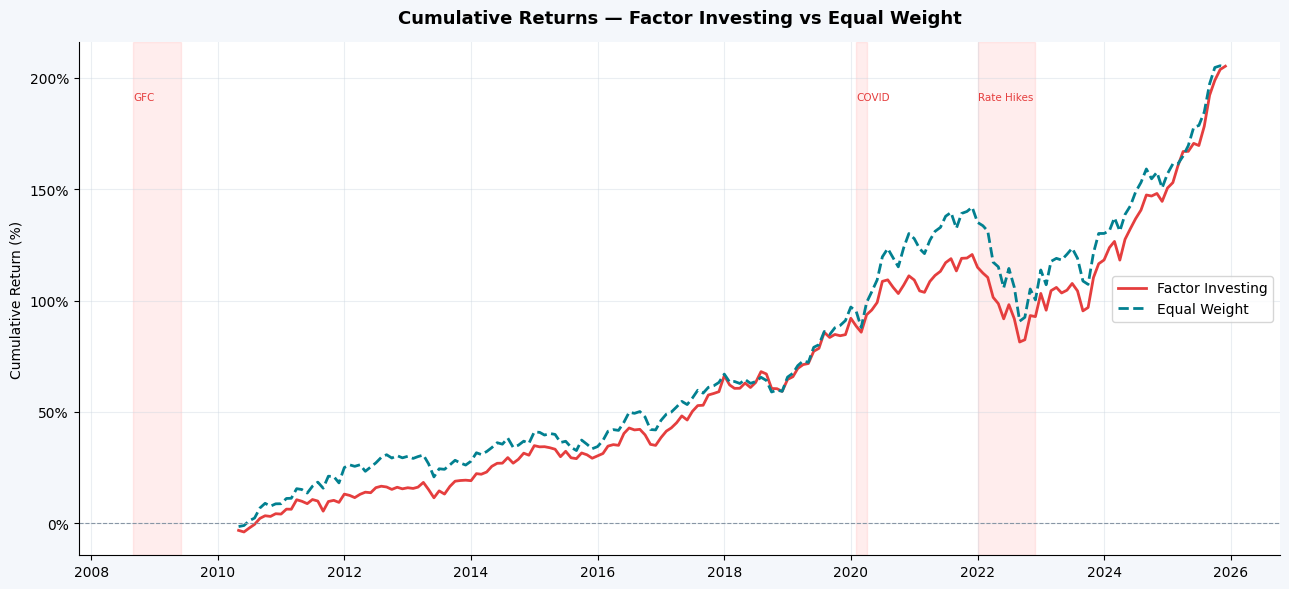

In [26]:
# ── Cell 7: Cumulative Returns ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 6))

for label, monthly_returns in all_strategies.items():
    cumulative_growth_pct = ((1 + monthly_returns).cumprod() - 1) * 100
    ax.plot(cumulative_growth_pct, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label == "Equal Weight" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Returns — Factor Investing vs Equal Weight",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

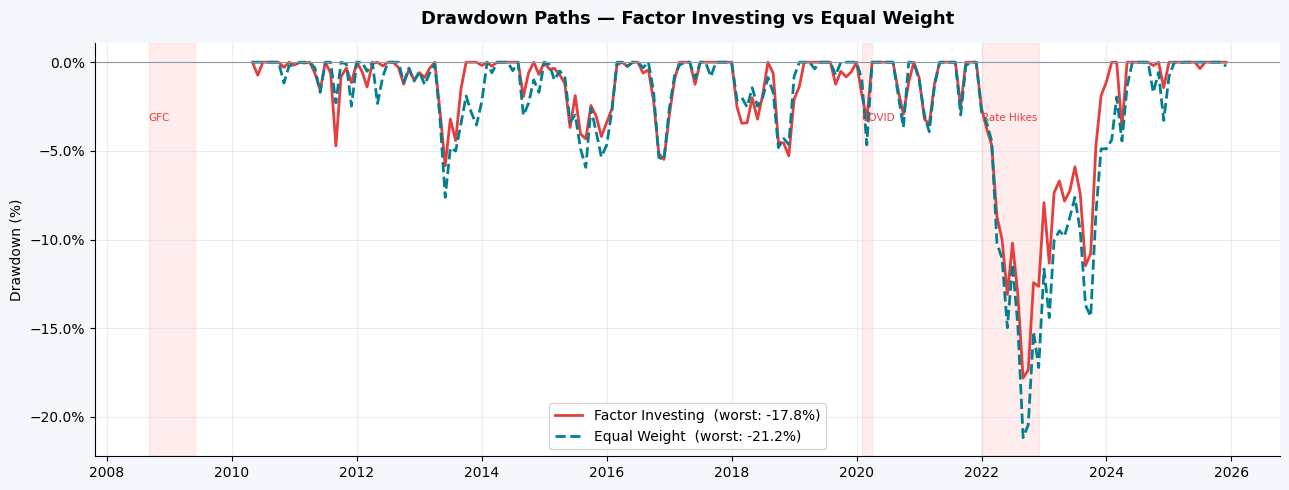

In [27]:
# ── Cell 8: Drawdown Paths ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_pct     = ((cumulative_value - rolling_peak) / rolling_peak) * 100
    ax.plot(drawdown_pct,
            label=f"{label}  (worst: {drawdown_pct.min():.1f}%)",
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label == "Equal Weight" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_min = ax.get_ylim()[0]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_min * 0.15,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — Factor Investing vs Equal Weight",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

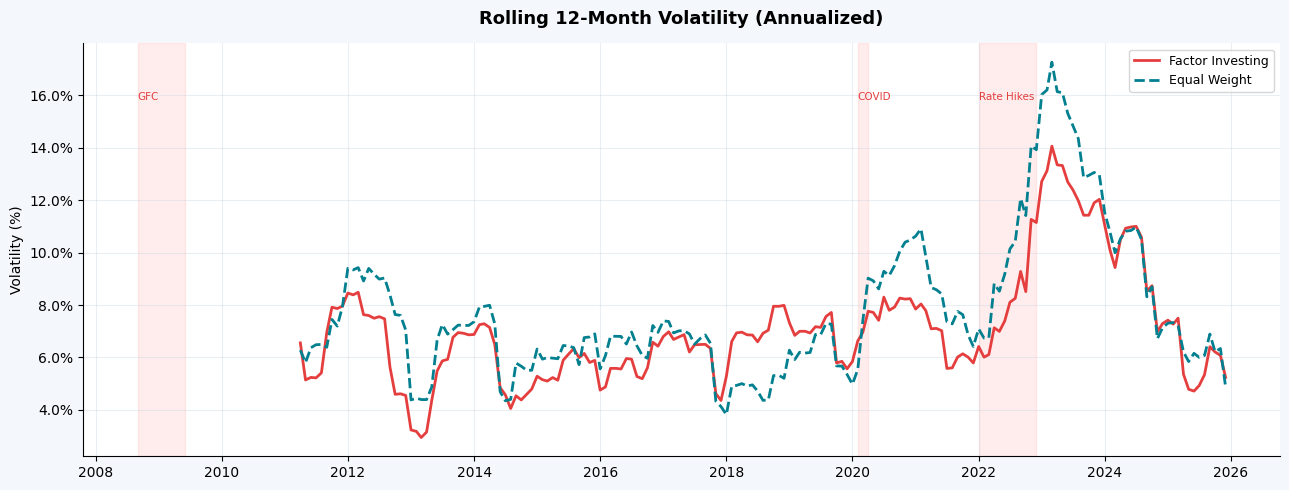

In [28]:
# ── Cell 9: Rolling 12-Month Volatility ───────────────────────────────────────

rolling_window_months = 12

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    rolling_vol = (
        monthly_returns.rolling(rolling_window_months).std() * np.sqrt(12) * 100
    )
    ax.plot(rolling_vol, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if label == "Equal Weight" else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {rolling_window_months}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
# ── Cell 10: Recovery Dynamics ────────────────────────────────────────────────

def months_to_recover(monthly_returns, crisis_start, crisis_end):
    cumulative_value  = (1 + monthly_returns).cumprod()
    pre_crisis_values = cumulative_value.loc[:crisis_start]
    if pre_crisis_values.empty:
        return None
    pre_crisis_peak   = pre_crisis_values.max()
    crisis_values     = cumulative_value.loc[crisis_start:crisis_end]
    if crisis_values.empty:
        return None
    trough_date       = crisis_values.idxmin()
    post_trough       = cumulative_value.loc[trough_date:]
    recovered_months  = post_trough[post_trough >= pre_crisis_peak]
    if recovered_months.empty:
        return None
    recovery_date     = recovered_months.index[0]
    months_elapsed    = len(cumulative_value.loc[trough_date:recovery_date]) - 1
    return months_elapsed


print("── Recovery Time (months from trough back to pre-crisis peak) ──\n")
print("Note: GFC shows 'Not recovered' because the 36-month rolling window")
print("means the simulation begins after the crisis onset. See Bookmark #5.\n")
header = f"{'Crisis':<16}" + "".join(f"{label:>24}" for label in all_strategies)
print(header)
print("-" * len(header))

for crisis_start, crisis_end, crisis_label in CRISES:
    row = f"{crisis_label:<16}"
    for label, monthly_returns in all_strategies.items():
        months = months_to_recover(monthly_returns, crisis_start, crisis_end)
        row += f"{'Not recovered':>24}" if months is None else f"{months} months".rjust(24)
    print(row)

── Recovery Time (months from trough back to pre-crisis peak) ──

Note: GFC shows 'Not recovered' because the 36-month rolling window
means the simulation begins after the crisis onset. See Bookmark #5.

Crisis                  Factor Investing            Equal Weight
----------------------------------------------------------------
GFC                        Not recovered           Not recovered
COVID                           1 months                1 months
Rate Hikes                     17 months               21 months


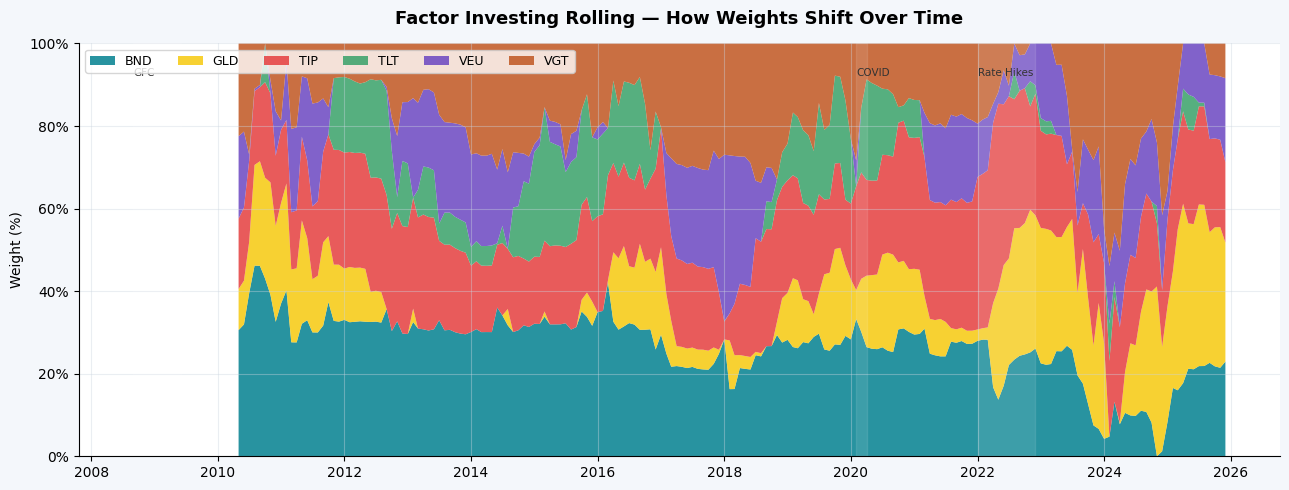

In [30]:
# ── Cell 11: Rolling Weight Evolution ────────────────────────────────────────
# Factor weights shift as scores change each month.
# Watch for: quality and low-vol pulling weights toward bonds during crises,
# momentum pulling toward VGT during tech bull runs.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    rolling_weights_df.index,
    [rolling_weights_df[asset] * 100 for asset in assets],
    labels=assets, colors=asset_colors, alpha=0.85
)

for crisis_start, crisis_end, _ in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.10, color="white", zorder=2)
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), 92,
            crisis_label, fontsize=7.5, color="#333")

ax.set_title("Factor Investing Rolling — How Weights Shift Over Time",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Weight (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, ncol=num_assets, loc="upper left")
plt.tight_layout()
plt.show()

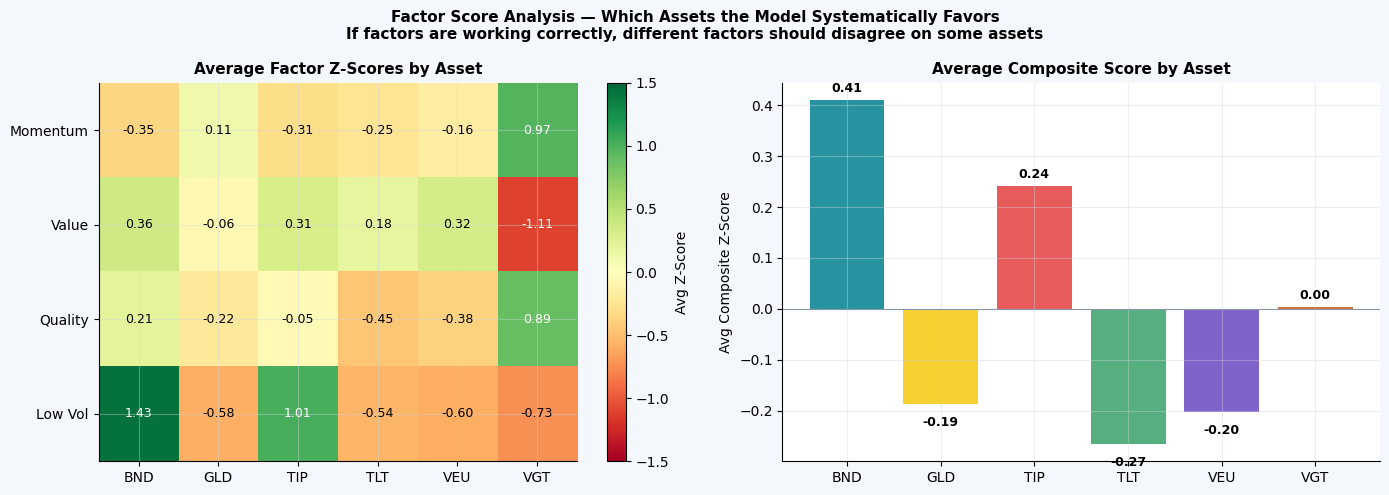


Factor correlation check (should NOT be close to -1.0 for value vs momentum):
  Momentum vs Value correlation: -0.225
  (Close to 0 = good separation. Close to -1 = factors cancel each other.)


In [31]:
# ── Cell 12: Factor Score Heatmap ────────────────────────────────────────────
# Shows the average z-score for each asset on each factor over the full
# simulation period. Reveals which assets were systematically favored
# or penalized by each factor — and whether the four factors are
# providing genuinely distinct signals (they should disagree on some assets).

factor_names = ["momentum", "value", "quality", "low_vol"]
avg_factor_scores = {}
for factor_name in factor_names:
    factor_cols = [f"{factor_name}_{asset}" for asset in assets]
    avg_factor_scores[factor_name] = factor_scores_df[factor_cols].mean().values

# Build matrix from dict (keys are factor names), then rename columns for display
factor_score_matrix = pd.DataFrame(
    avg_factor_scores,
    index=assets
).astype(float)
factor_score_matrix.columns = ["Momentum", "Value", "Quality", "Low Vol"]

composite_cols = [f"composite_{asset}" for asset in assets]
avg_composite  = factor_scores_df[composite_cols].mean()
avg_composite.index = assets

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-factor z-score heatmap
heatmap = ax_left.imshow(factor_score_matrix.values.T,
                          cmap="RdYlGn", aspect="auto", vmin=-1.5, vmax=1.5)
plt.colorbar(heatmap, ax=ax_left, label="Avg Z-Score")
ax_left.set_xticks(range(num_assets))
ax_left.set_yticks(range(len(factor_names)))
ax_left.set_xticklabels(assets, fontsize=10)
ax_left.set_yticklabels(["Momentum", "Value", "Quality", "Low Vol"], fontsize=10)
for row_idx in range(len(factor_names)):
    for col_idx in range(num_assets):
        val = factor_score_matrix.values[col_idx, row_idx]
        ax_left.text(col_idx, row_idx, f"{val:.2f}",
                     ha="center", va="center", fontsize=9,
                     color="white" if abs(val) > 0.8 else "black")
ax_left.set_title("Average Factor Z-Scores by Asset",
                   fontsize=11, fontweight="bold")

# Right: average composite score
colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]
bars = ax_right.bar(assets, avg_composite.values, color=colors, alpha=0.85)
ax_right.axhline(0, color="#8896A5", linewidth=0.8)
for bar, val in zip(bars, avg_composite.values):
    ax_right.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + (0.01 if val >= 0 else -0.05),
                  f"{val:.2f}",
                  ha="center", va="bottom", fontsize=9, fontweight="bold")
ax_right.set_title("Average Composite Score by Asset",
                    fontsize=11, fontweight="bold")
ax_right.set_ylabel("Avg Composite Z-Score")

fig.suptitle(
    "Factor Score Analysis — Which Assets the Model Systematically Favors\n"
    "If factors are working correctly, different factors should disagree on some assets",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("\nFactor correlation check (should NOT be close to -1.0 for value vs momentum):")
mom_scores  = factor_scores_df[[f"momentum_{a}" for a in assets]].values.flatten()
val_scores  = factor_scores_df[[f"value_{a}"    for a in assets]].values.flatten()
correlation = np.corrcoef(mom_scores, val_scores)[0, 1]
print(f"  Momentum vs Value correlation: {correlation:.3f}")
print(f"  (Close to 0 = good separation. Close to -1 = factors cancel each other.)")

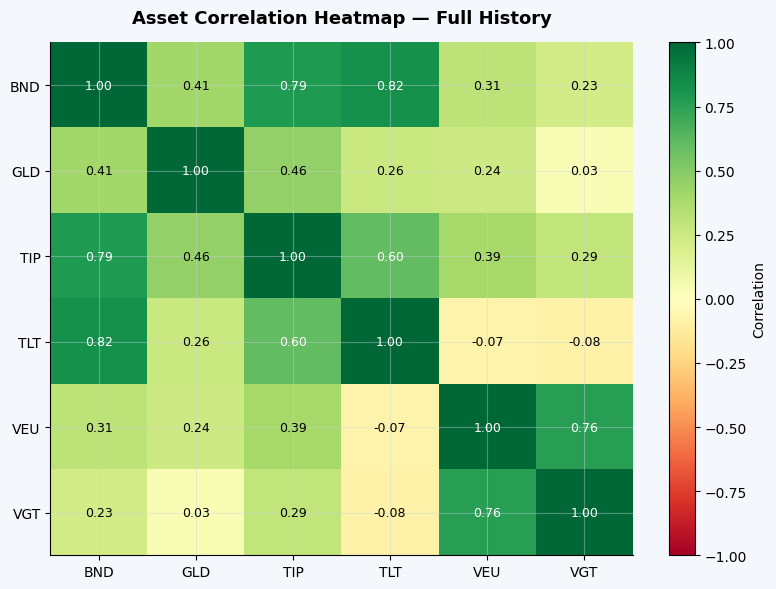

In [32]:
# ── Cell 13: Correlation Heatmap ──────────────────────────────────────────────

correlation_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
colormap = plt.cm.RdYlGn
heatmap  = ax.imshow(correlation_matrix, cmap=colormap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(heatmap, ax=ax, label="Correlation")

ax.set_xticks(range(num_assets))
ax.set_yticks(range(num_assets))
ax.set_xticklabels(assets, fontsize=10)
ax.set_yticklabels(assets, fontsize=10)

for row_index in range(num_assets):
    for col_index in range(num_assets):
        correlation_value = correlation_matrix.iloc[row_index, col_index]
        text_color        = "white" if abs(correlation_value) > 0.6 else "black"
        ax.text(col_index, row_index,
                f"{correlation_value:.2f}",
                ha="center", va="center",
                fontsize=9, color=text_color)

ax.set_title("Asset Correlation Heatmap — Full History",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()